# Notebook 2: Exploratory Data Analysis (EDA) 


The process conducted in this notebook involves the application of an Exploratory Data Analysis on the ‘candidates’ data migrated to the MySQL database.Basically, Exploratory Data Analysis (EDA) is the process of visually and statistically summarizing, exploring, and understanding the main characteristics, patterns, and relationships within a dataset.

### Importing libraries and modules


`sys.path.append()` allows importing modules from directories that are not in the default Python search path, which is necessary in this case to reuse a module created in the “source/connection/db_utils.py” directory of the project dedicated to the database utilities, like establishing and closing the connection to the database.

In [1]:
import os
import sys
import numpy as np 
import pandas as pd
import re
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from fuzzywuzzy import process
import pycountry
sys.path.append(os.path.abspath('../src'))
from connection.db_utils import get_connection, close_connection

### Establishing the database connection

A SQLite engine object is created using the module `get_connection` located in the project´s `/src/connection/db_utils.py` script. Then, a connection object is created by connecting the engine.

In [2]:
engine = get_connection()

Engine created succesfully


### Reading the candidates data from the PosgreSQL database

The pandas library's `read_sql_table` function is employed to retrieve data directly from the PostgresSQL database table named "candidates_raw". This function requires an active database connection, represented by the connection variable, to execute the necessary SQL query. All the data from the "candidates_raw" table is then loaded into a pandas DataFrame, which is assigned to the variable ``df`. This effectively transfers the table's contents into a data structure suitable for analysis and manipulation within Python.

Following the data retrieval, the `df.head(3)` method is invoked. This command displays the first three rows of the DataFrame, providing a concise preview of the data. This allows for immediate verification that the data was successfully extracted from the SQL table and offers a quick look at the structure and initial records of the dataset, facilitating a basic understanding of the data's format and content.

In [3]:
if engine:
    df = pd.read_sql_table("candidates_raw", engine)

    if 'Application Date' in df.columns:
        df['Application Date'] = pd.to_datetime(df['Application Date'], dayfirst=True)

df.head(3)

,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9


In [4]:
close_connection(engine)

Engine connection closed.


### Data profiling

Data profiling is an invaluable step in the data preparation process. While it doesn’t fully automate data type mapping, it provides crucial insights needed to make informed decisions and create a well-designed database schema in the future.

#### Shape of the data

We get the shape of the data using Pandas `shape` method.

In [5]:
df.shape

(50000, 10)

This means that this dataset has 50000 rows and 10 columns.

#### Data types

We inspect the columns and their data types using the Pandas `info()` method.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   First Name                 50000 non-null  object        
 1   Last Name                  50000 non-null  object        
 2   Email                      50000 non-null  object        
 3   Application Date           50000 non-null  datetime64[ns]
 4   Country                    50000 non-null  object        
 5   YOE                        50000 non-null  int64         
 6   Seniority                  50000 non-null  object        
 7   Technology                 50000 non-null  object        
 8   Code Challenge Score       50000 non-null  int64         
 9   Technical Interview Score  50000 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 3.8+ MB


We can see that the DataFrame contains 3 columns with the "int64" data type and 7 columns with the "object" data type, and this data types are optimal for our analysis.

#### Data cardinality

It helps identify the number of distinct categories in a column, which is essential for analyzing categorical variables.

It measures the "cardinality" of a column, which is the number of unique values. High cardinality means many unique values, while low cardinality means few.

In [7]:
df.nunique()

First Name                    3007
Last Name                      474
Email                        49833
Application Date              1646
Country                        244
YOE                             31
Seniority                        7
Technology                      24
Code Challenge Score            11
Technical Interview Score       11
dtype: int64

* **"First Name 3007":** This means there are 3,007 distinct first names in the "First Name" column.
* **"Last Name 474":** There are 474 unique last names. This indicates less diversity compared to first names, potentially suggesting some last names are repeated more frequently.
* **"Email 49833":** This shows 49,833 unique email addresses. Given that the data has 50,000 rows, this suggests that almost every row has a unique email, which is expected, but emails should be unique for each candidate, so this also sugests a duplication problem.
* **"Application Date 1646":** There are 1,646 unique application dates. This indicates that applications were submitted on a variety of different days.
* **"Country 244":** There are 244 distinct countries represented in the dataset. This is suspicious there are 195  recognized countries in the world.
* **"YOE 31":** "YOE" likely stands for "Years of Experience." There are 31 unique values, meaning applicants have a range of experience levels.
* **"Seniority 7":** There are 7 unique seniority levels. This suggests a relatively small number of defined seniority categories.
* **"Technology 24":** There are 24 unique technologies listed. This indicates a variety of technical skills among the applicants.
* **"Code Challenge Score 11":** There are 11 unique scores for the code challenge. This likely means the scores are discrete or binned into a limited number of categories.
* **"Technical Interview Score 11":** Similar to the code challenge score, there are 11 unique technical interview scores.

#### Describe

We get quick summary of the dataset using the Pandas `describe()` method. The `describe()` function applies basic statistical computations on the dataset like extreme values, count of data points standard deviation, etc. Any missing value or NaN value is automatically skipped. `describe()` function gives a good picture of the distribution of data.

Note we can also get the description of categorical columns of the dataset if we specify `include ='all'`  in the describe function.




In [8]:
df.describe(include='all') 

,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
count,50000,50000,50000,50000,50000,50000.000000,50000,50000,50000.000000,50000.000000
unique,3007,474,49833,NaN,244,NaN,7,24,NaN,NaN
top,Sarai,Murazik,marianne31@yahoo.com,NaN,Malawi,NaN,Intern,Game Development,NaN,NaN
freq,33,138,3,NaN,242,NaN,7255,3818,NaN,NaN
mean,NaN,NaN,NaN,2020-04-03 23:04:14.592000,NaN,15.286980,NaN,NaN,4.996400,5.003880
min,NaN,NaN,NaN,2018-01-01 00:00:00,NaN,0.000000,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,2019-02-17 00:00:00,NaN,8.000000,NaN,NaN,2.000000,2.000000
50%,NaN,NaN,NaN,2020-04-06 00:00:00,NaN,15.000000,NaN,NaN,5.000000,5.000000
75%,NaN,NaN,NaN,2021-05-21 00:00:00,NaN,23.000000,NaN,NaN,8.000000,8.000000
max,NaN,NaN,NaN,2022-07-04 00:00:00,NaN,30.000000,NaN,NaN,10.000000,10.000000


The most common country where applicants are from is Malawi, and their most fr

### Handling Missing Values

Missing Data can also refer to as NA(Not Available) values in pandas. There are several useful functions for detecting, removing, and replacing null values in Pandas DataFrame. To detect missing values in the DataFrame `df.isnull().sum()` is used.


In [9]:
df.isnull().sum()

First Name                   0
Last Name                    0
Email                        0
Application Date             0
Country                      0
YOE                          0
Seniority                    0
Technology                   0
Code Challenge Score         0
Technical Interview Score    0
dtype: int64

The output confirms that there is no null data in the dataset.

### Exploring data characteristics

By exploring the characteristics of the data very well, one can gain treasured insights into its structure, pick out capability problems or anomalies, and inform the subsequent evaluation and modeling choices. Documenting any findings or observations from this step is critical, as they may be relevant for destiny reference or communication with stakeholders.

#### Geographical distribution

Seaborn's barplot is used to visualize the top 20 countries with the highest applicant counts.

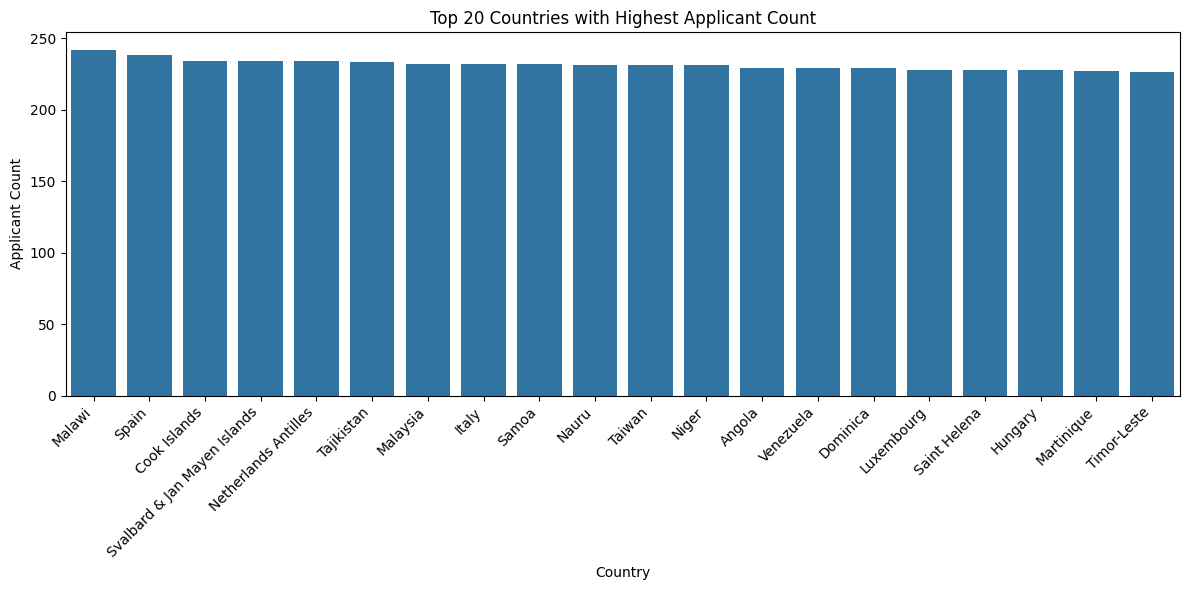

In [10]:
country_counts = df['Country'].value_counts().head(20)  
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Countries with Highest Applicant Count')
plt.xlabel('Country')
plt.ylabel('Applicant Count')
plt.tight_layout()
plt.show()

Filters the DataFrame to include only the top 20 countries and top 5 technologies for clarity.
Uses groupby and unstack to create a pivot table for the grouped bar chart.
Visualizes the relationship between countries and technologies.

<Figure size 1500x800 with 0 Axes>

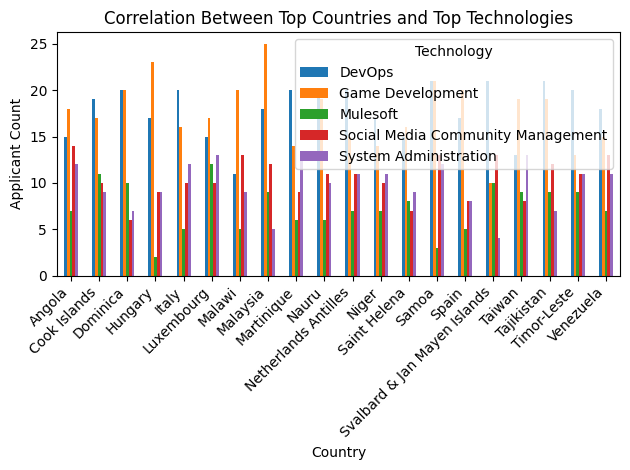

In [11]:
# 3. Correlation Between Country and Technology (Grouped Bar Chart)
top_countries = df['Country'].value_counts().head(20).index  # Top 10 countries
top_technologies = df['Technology'].value_counts().head(5).index  # Top 5 technologies

filtered_df = df[df['Country'].isin(top_countries) & df['Technology'].isin(top_technologies)]
grouped_data = filtered_df.groupby(['Country', 'Technology']).size().unstack(fill_value=0)
plt.figure(figsize=(15, 8))
grouped_data.plot(kind='bar', stacked=False)
plt.title('Correlation Between Top Countries and Top Technologies')
plt.xlabel('Country')
plt.ylabel('Applicant Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

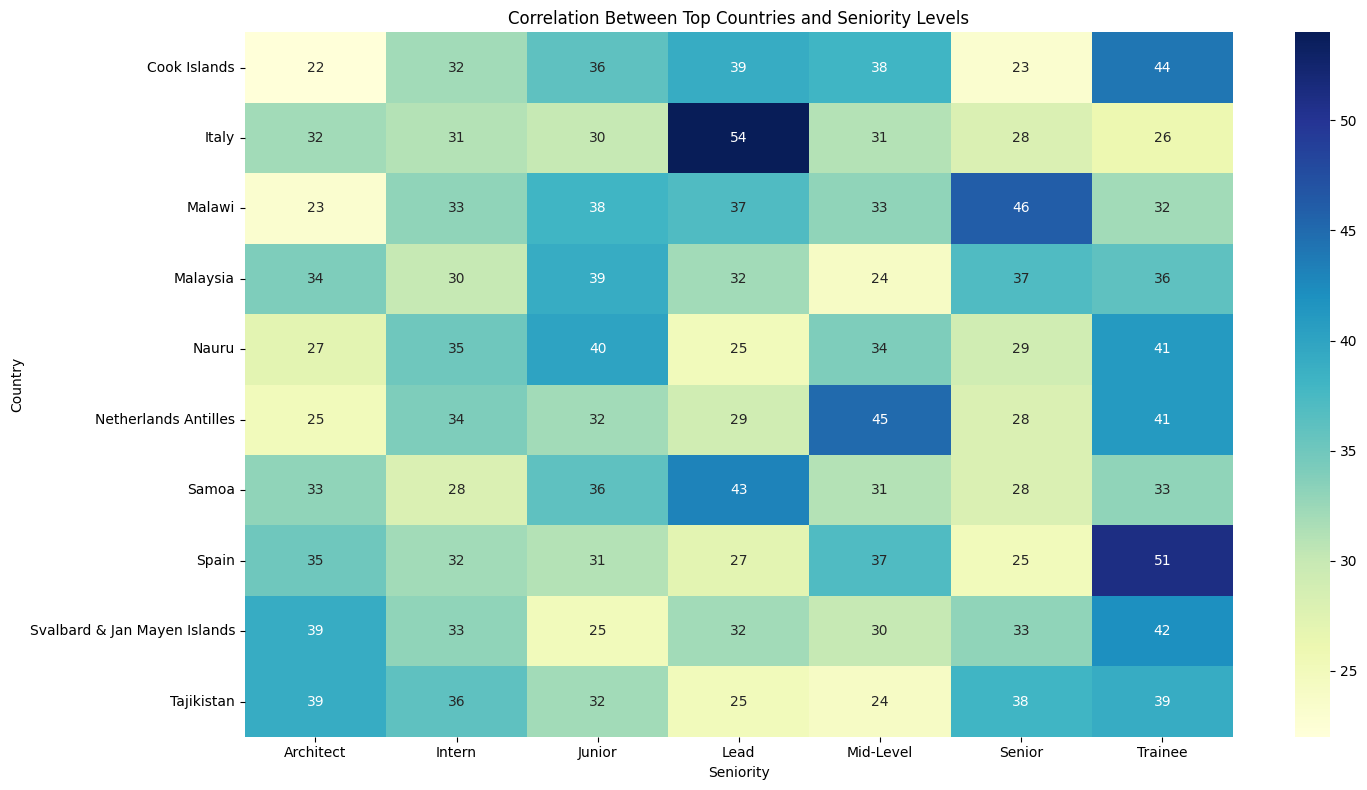

In [12]:
# 4. Correlation Between Country and Seniority (Heatmap)
top_countries = df['Country'].value_counts().head(10).index
seniority_levels = df['Seniority'].unique()

filtered_df = df[df['Country'].isin(top_countries)]
grouped_data = filtered_df.groupby(['Country', 'Seniority']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 8))
sns.heatmap(grouped_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation Between Top Countries and Seniority Levels')
plt.xlabel('Seniority')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

#### Experience Level Analysis

### Transformations (Part 1)

#### Column names


Database table names, column names, index names, etc. should follow a naming convention that ensures high readability and uses the English language (in general). In this case the columns follow the guidelines, but can be formated to be in lowercase letters, and their spaces replaced by underscores.

The first line of code, focuses on standardizing column names by replacing spaces with underscores. This is achieved by accessing the column names through `df.columns`, using the `.str` accessor to apply string operations element-wise, and then utilizing the `.replace(' ', '_')` method to perform the substitution. The modified column names are then reassigned back to `df.columns`.

Following this, the second line further cleans the column names by converting all characters to lowercase. The `df.rename()` method is employed with the `columns=str.lower` argument, which applies the `str.lower` function to each column name. The result is a new DataFrame with all column names in lowercase


In [13]:
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns=str.lower)
df.rename(columns={"yoe": "years_of_experience"}, inplace=True)

df.head()

,first_name,last_name,email,application_date,country,years_of_experience,seniority,technology,code_challenge_score,technical_interview_score
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9
3,Arch,Spinka,elvera_kulas@yahoo.com,2020-10-01,Eritrea,25,Trainee,QA Manual,7,1
4,Larue,Altenwerth,minnie.gislason@gmail.com,2020-05-20,Myanmar,13,Mid-Level,Social Media Community Management,9,7


Now all columns are in *Snake case* , a way of writing phrases without spaces, where spaces are replaced with underscores, and the words are typically all lower case. 

#### Obtaining the hired candidates

A candidate is considered HIRED when she/he has both scores greater than or equal to 7.

In [14]:
def mark_hired_candidates(df):

    df['hired'] = (df['code_challenge_score'] >= 7) & (df['technical_interview_score'] >= 7)
    return df

mark_hired_candidates(df)
df.head()

,first_name,last_name,email,application_date,country,years_of_experience,seniority,technology,code_challenge_score,technical_interview_score,hired
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3,False
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10,False
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9,True
3,Arch,Spinka,elvera_kulas@yahoo.com,2020-10-01,Eritrea,25,Trainee,QA Manual,7,1,False
4,Larue,Altenwerth,minnie.gislason@gmail.com,2020-05-20,Myanmar,13,Mid-Level,Social Media Community Management,9,7,True


#### Verifying input values in "seniority" and technology "columns"

A simple `for` loop to print the unique values in the seniority and technology columns of the dataset. Printing the unique values in dataset columns like "seniority" and "technology" can help verify there are no invalid or incorrect inputs. By inspecting the unique values, one can quickly identify any unexpected entries (e.g., typos, inconsistent formatting, or irrelevant values) that might cause issues in data processing or analysis.


In [15]:
def print_unique_values(df):
    columns_to_check = ['seniority', 'technology']
    
    for column in columns_to_check:
        print(f"Unique values in column '{column}':")
        print(df[column].unique())
        print()  

print_unique_values(df)

Unique values in column 'seniority':
['Intern' 'Mid-Level' 'Trainee' 'Junior' 'Lead' 'Architect' 'Senior']

Unique values in column 'technology':
['Data Engineer' 'Client Success' 'QA Manual'
 'Social Media Community Management' 'Adobe Experience Manager' 'Sales'
 'Mulesoft' 'DevOps' 'Development - CMS Backend' 'Salesforce'
 'System Administration' 'Security' 'Game Development'
 'Development - CMS Frontend' 'Security Compliance'
 'Development - Backend' 'Design'
 'Business Analytics / Project Management' 'Development - Frontend'
 'Development - FullStack' 'Business Intelligence'
 'Database Administration' 'QA Automation' 'Technical Writing']



In this cases there are not evident inlavid inputs:

- **Seniority:** All the values seem valid and consistent, representing typical seniority levels (e.g., Intern, Mid-Level, Lead, etc.). There are no obvious invalid inputs here.

- **Technology:** The entries also look reasonable, covering a wide range of roles and areas (e.g., Data Engineer, DevOps, Salesforce, etc.). There don’t appear to be typos or strange inputs.

#### Country validation

Validate and clean the 'country' column using fuzzy matching and pycountry.

In [16]:
def validate_and_clean_countries(df):
    # Generate the reference country list once
    reference_countries = [country.name for country in pycountry.countries]

    # Create a mapping of input countries to their corrected matches
    corrected_countries = {}
    corrections_count = 0  # Counter for the number of corrections
    corrected_country_list = set()  # To store unique corrected country names
    flagged_rows_count = 0  # Counter for unknown countries

    def correct_country(country):
        nonlocal corrections_count, flagged_rows_count  # Allow modification of the counters

        if pd.isna(country):
            flagged_rows_count += 1  # Increment the flag count for NaN entries
            return country  # Keep the original value (even if NaN)

        if country in corrected_countries:  # Use cached result if available
            return corrected_countries[country]

        match, score = process.extractOne(country, reference_countries)
        if score >= 80:  # If a valid match is found
            corrected_countries[country] = match
            if country != match:  # Count as a correction if the name changes
                corrections_count += 1
                corrected_country_list.add(match)  # Add to the list of corrected countries
            return match
        else:
            flagged_rows_count += 1  # Increment the flag count for unknown entries
            corrected_countries[country] = country  # Retain the original value
            return country

    # Correct the 'country' column directly
    df['country'] = df['country'].map(correct_country)

    # Generate a new column to flag rows with unknown countries
    df['unknown_country_flag'] = df['country'].apply(
        lambda x: pd.isna(x) or x not in reference_countries
    )

    # Print the metrics
    print(f"Total number of country names corrected: {corrections_count}")
    print(f"Total unique corrected countries: {len(corrected_country_list)}")
    print(f"List of corrected countries: {corrected_country_list}")
    print(f"Total number of rows flagged as unknown: {flagged_rows_count}")

    return df


In [17]:
validate_and_clean_countries(df)

Total number of country names corrected: 30
Total unique corrected countries: 29
List of corrected countries: {'Central African Republic', 'British Indian Ocean Territory', 'Bouvet Island', 'North Macedonia', 'Moldova, Republic of', 'Tanzania, United Republic of', 'Libya', 'Saint Barthélemy', 'Bolivia, Plurinational State of', 'Réunion', 'Antarctica', 'Cabo Verde', 'Slovakia', 'Korea, Republic of', 'Netherlands', 'Saint Martin (French part)', 'Virgin Islands, U.S.', "Korea, Democratic People's Republic of", 'Micronesia, Federated States of', 'Viet Nam', 'Svalbard and Jan Mayen', 'Pitcairn', 'Iran, Islamic Republic of', 'Saint Helena, Ascension and Tristan da Cunha', 'United States', 'Venezuela, Bolivarian Republic of', 'Virgin Islands, British', 'Taiwan, Province of China', "Côte d'Ivoire"}
Total number of rows flagged as unknown: 3


,first_name,last_name,email,application_date,country,years_of_experience,seniority,technology,code_challenge_score,technical_interview_score,hired,unknown_country_flag
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3,False,False
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10,False,False
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9,True,False
3,Arch,Spinka,elvera_kulas@yahoo.com,2020-10-01,Eritrea,25,Trainee,QA Manual,7,1,False,False
4,Larue,Altenwerth,minnie.gislason@gmail.com,2020-05-20,Myanmar,13,Mid-Level,Social Media Community Management,9,7,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Bethany,Shields,rocky_mitchell@hotmail.com,2022-01-09,Dominican Republic,27,Trainee,Security,2,1,False,False
49996,Era,Swaniawski,dolores.roob@hotmail.com,2020-06-02,Morocco,21,Lead,Game Development,1,2,False,False
49997,Martin,Lakin,savanah.stracke@gmail.com,2018-12-15,Uganda,20,Trainee,System Administration,6,1,False,False
49998,Aliya,Abernathy,vivienne.fritsch@yahoo.com,2020-05-30,Central African Republic,20,Senior,Database Administration,0,0,False,False


This output means that the dataset had 30 instances of country names that were corrected. Out of these corrections, 29 were unique country names, which indicates that one country name was corrected multiple times (likely because it appeared in the dataset more than once and was corrected in each instance).

In [18]:
unique_countries = df['country'].unique()
print(len(unique_countries))

241


After validation, there are 241 unique countries, and initially there were 244. Some entries might have been regions, territories, or other geopolitical entities that pycountry recognizes, but one might not consider as independent countries; or the names of the countries were typed in a non standard form.

##### Inspecting registers flagged with "Unknown" country

The rows (3 in this case) flagged by the `unknown_country_flag` does not contain a valid or recognizable country name, and instead has been replaced with the placeholder.This helps identify which rows might need further attention or correction.

To proceed, we extract the unique values of countries flagged as unknown.

In [19]:
unknown_countries = df[df['unknown_country_flag'] == True]['country'].unique()

print("Unique unknown countries:", unknown_countries)

Unique unknown countries: ['Palestinian Territory' 'Turkey' 'Swaziland']


**Why this happens:**

- **Swaziland:** The country officially changed its name to Eswatini in 2018. If `pycountry`´s reference list is up-to-date, older names like "Swaziland" might not match.

- **Palestinian Territory:** This might not exist in `pycountry`´s reference list as it might only contain recognized sovereign states.

- **Turkey:** The country officially requested to use its name Türkiye in international contexts instead of "Turkey."

##### Handling registers flagged with "Unknown" country

We are going to apply corrections to the country column, reeplacing outdated country names with their current, officially recognized counterparts. This is accomplished thought the Pandas `.replace()` method and a dictionary.

In [20]:
custom_corrections = {
    'Swaziland': 'Eswatini',
    'Palestinian Territory': 'State of Palestine',
    'Turkey': 'Türkiye'
}

df['country'] = df['country'].replace(custom_corrections)

Now, the column used for the validation process can be droped.

In [21]:
df = df.drop(columns=['unknown_country_flag'])
df.head(3)

,first_name,last_name,email,application_date,country,years_of_experience,seniority,technology,code_challenge_score,technical_interview_score,hired
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3,False
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10,False
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9,True


In [22]:
unique_countries = df['country'].unique()
print(unique_countries)

['Norway' 'Panama' 'Belarus' 'Eritrea' 'Myanmar' 'Zimbabwe'
 'Wallis and Futuna' 'Italy' 'Timor-Leste' 'Armenia'
 'French Southern Territories' 'Chad' 'El Salvador' 'Mozambique'
 'Brunei Darussalam' 'Morocco'
 'Saint Helena, Ascension and Tristan da Cunha' 'Portugal'
 'Central African Republic' 'Seychelles' 'Dominica' 'Finland' 'Belgium'
 'Niue' 'Japan' 'State of Palestine' 'Faroe Islands' 'Latvia'
 'Saudi Arabia' 'Poland' 'Micronesia, Federated States of' 'Macao'
 'Bangladesh' 'Taiwan, Province of China' 'Slovakia' 'Mexico' 'Nigeria'
 'Guadeloupe' 'Bosnia and Herzegovina' 'Guyana' 'Croatia'
 'Svalbard and Jan Mayen' 'Yemen' 'Ukraine' 'Zambia' 'Paraguay'
 'Puerto Rico' 'Madagascar' 'Bulgaria' 'Jersey' 'French Polynesia'
 'United States' 'Mali' 'Anguilla' 'Holy See (Vatican City State)'
 'Andorra' 'Korea, Republic of' 'Türkiye'
 'Heard Island and McDonald Islands' 'Malta' 'Liechtenstein'
 'Equatorial Guinea' 'Algeria' 'Falkland Islands (Malvinas)' 'Ecuador'
 'Jamaica' 'San Marino' 'Mala

#### E-mail duplicates

As signaled before in the "Data cardinality" section, there is a duplication problem with the e-mails, as these should be unique for each candidate. But before adressing this issue, validating email addresses comes first.

In [23]:
def validate_with_regex(email):

    pattern = r"^[\w\.-]+@[a-zA-Z0-9\.-]+\.[a-zA-Z]{2,}$"
    return bool(re.match(pattern, email))


def validate_email_column(df):

    df['email_valid'] = df['email'].apply(validate_with_regex)

    return df

df = validate_email_column(df)

invalid_emails = df[df['email_valid'] == False]
print("Invalid Emails:")
print(invalid_emails['email'])

Invalid Emails:
Series([], Name: email, dtype: object)


There are not invalid emails in the dataset. But there are 332 rows with duplicated emails.

In [24]:
duplicate_emails = df[df.duplicated(subset=['email'], keep=False)]
duplicate_emails["email"].value_counts()
print(f"Found {len(duplicate_emails)} rows with duplicate emails.")


Found 332 rows with duplicate emails.


In [25]:
# Check if the DataFrame is ordered by date
is_ordered = df['application_date'].is_monotonic_increasing
print(is_ordered)

False


In [26]:
# Sort the DataFrame by the 'date' column
df = df.sort_values(by='application_date')
is_ordered = df['application_date'].is_monotonic_increasing
print(is_ordered)

True


In [27]:
df.shape

(50000, 12)

The function `process_candidate_uniqueness(df)` ensures candidate uniqueness by generating a unique key (candidate_key) based on first_name, last_name, and email. It identifies duplicate candidates with the same key, marks them as not unique, and drops those rows. It also checks if unique candidates have multiple application dates and flags this information in a new column, different_application_dates. Finally, it prints the number of duplicate rows removed and returns the cleaned DataFrame without the candidate_key column.

The function `filter_hired_candidates(df)` processes a dataset to retain only rows where the hired column is True, effectively filtering for hired candidates. It then removes duplicate entries based on the email column, keeping only the first occurrence of each duplicate, assuming the dataset is ordered by date. The result is a cleaned DataFrame with unique, hired candidates.

def filter_hired_candidates(df):

    df = df[df['hired'] == True]
    
    df = df.drop_duplicates(subset='email', keep='first')
    
    return df

filter_hired_candidates(df)

def flag_multiple_application_dates(df):
    # Create a unique key for each candidate based on their first name, last name, and email
    df['candidate_key'] = df['first_name'] + '_' + df['last_name'] + '_' + df['email']

    # Flag candidates with multiple application dates
    df['multiple_application_dates'] = df.groupby('candidate_key')['application_date'].transform('nunique') > 1

    # Drop the temporary candidate_key column
    df.drop('candidate_key', axis=1, inplace=True)

    return df


def process_candidate_uniqueness(df):

    df['unique_candidate'] = True  # Initialize uniqueness flag
    df['different_application_dates'] = False #initialize different dates flag

    # Create candidate key
    df['candidate_key'] = df['first_name'] + '_' + df['last_name']  + '_' + df['email']

    # Find duplicate candidate keys
    duplicate_keys = df[df.duplicated(subset=['candidate_key'], keep=False)]

    # Mark duplicates as False
    df.loc[duplicate_keys.index, 'unique_candidate'] = False

    # Check for different application dates among unique candidates
    unique_candidates = df[df['unique_candidate']]  # Only process unique candidates

    for key, group in unique_candidates.groupby('candidate_key'):
        if len(group['application_date'].unique()) > 1:
            df.loc[group.index, 'different_application_dates'] = True

    #count how many rows will be dropped.
    original_row_count = len(df)
    df_dropped = df[df['unique_candidate'] == False]
    rows_dropped = len(df_dropped)

    #drop the rows.
    df = df[df['unique_candidate'] == True]

    #print the number of rows dropped.
    print(f"Number of rows dropped: {rows_dropped}")

    df.drop('candidate_key', axis=1, inplace=True)
    return df


process_candidate_uniqueness(df)